In [247]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 

warnings.filterwarnings('ignore')

In [248]:
df = pd.read_csv('insurance.csv')

In [249]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [250]:
df.shape

(1338, 7)

In [251]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [252]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [253]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [254]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [255]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [256]:
numeric_columns = ['age', 'bmi', 'children', 'charges']

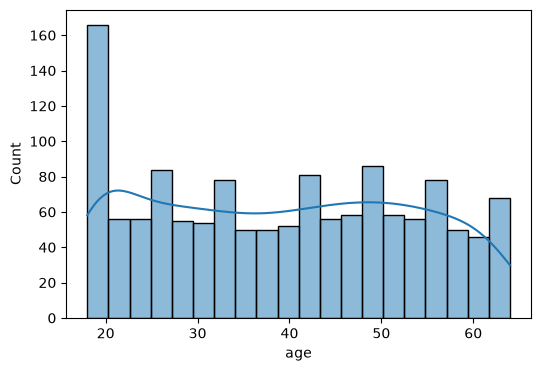

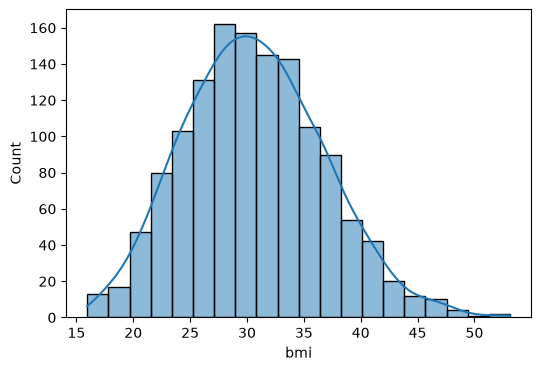

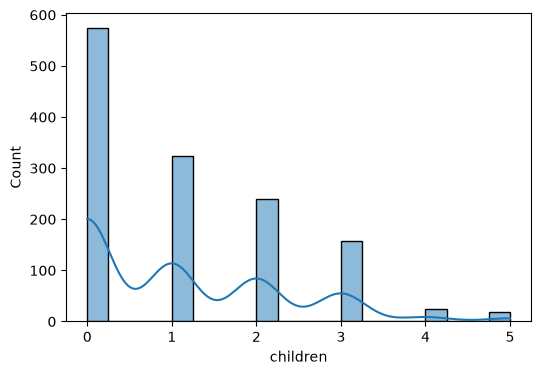

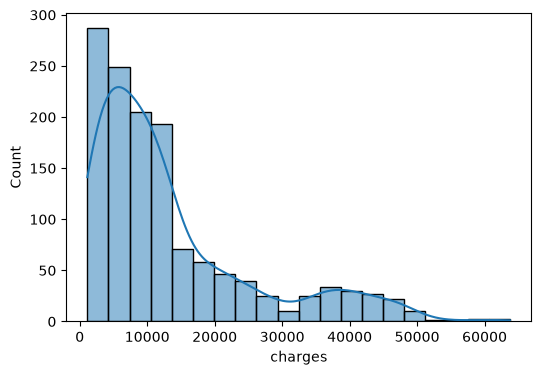

In [257]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

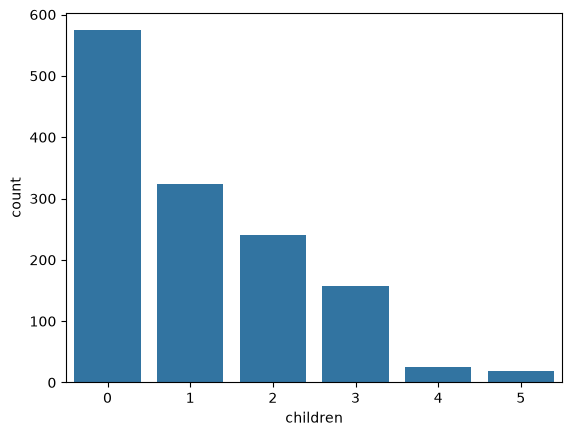

In [258]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

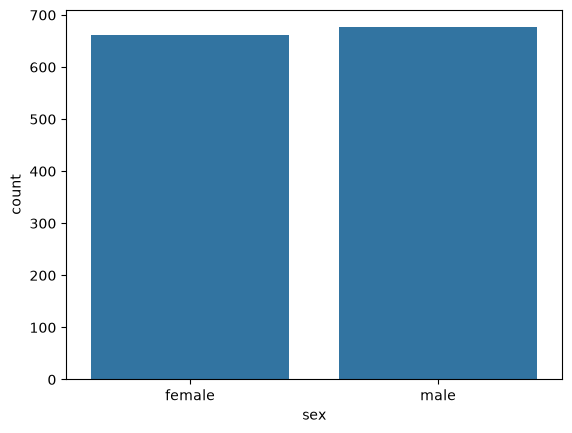

In [259]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

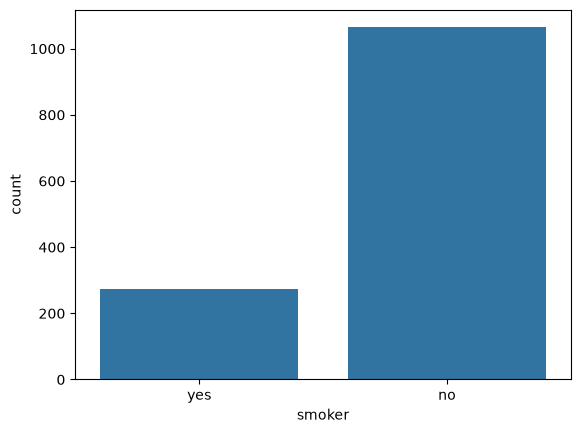

In [260]:
sns.countplot(x=df['smoker'])

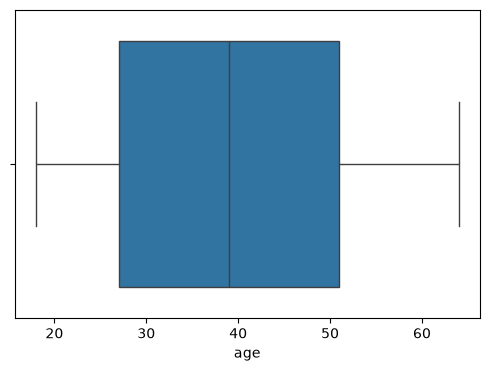

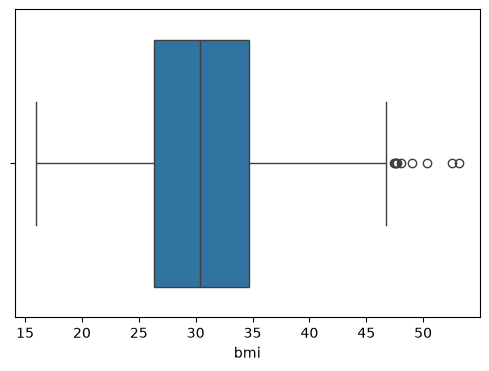

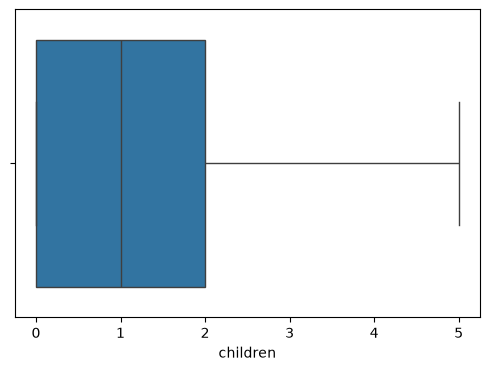

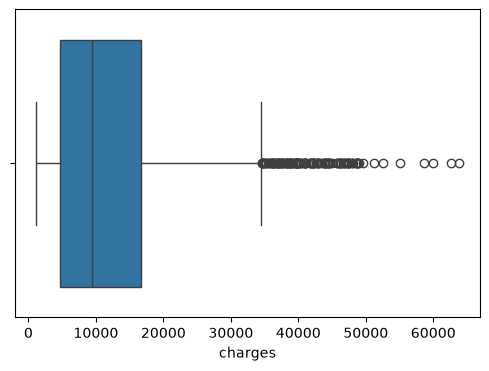

In [261]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

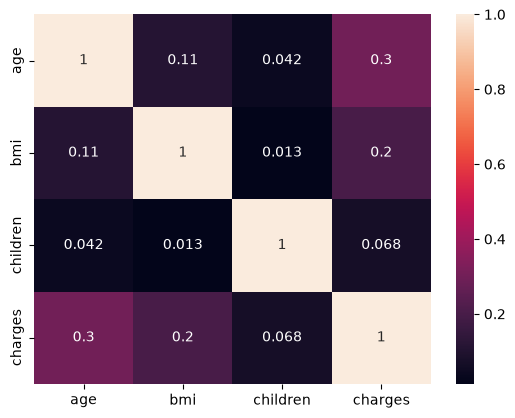

In [262]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and pre processing 

In [263]:
df.shape

(1338, 7)

In [264]:
df.drop_duplicates(inplace=True)

In [265]:
df_clean = df.copy()
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [266]:
df.shape

(1337, 7)

In [267]:
df_clean.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [268]:
df_clean.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [269]:
df_clean['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [270]:
df_clean['sex']=df_clean['sex'].map({'male':0,'female':1})

In [271]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,northwest,10600.54830
1334,18,1,31.920,0,no,northeast,2205.98080
1335,18,1,36.850,0,no,southeast,1629.83350
1336,21,1,25.800,0,no,southwest,2007.94500


In [272]:
df_clean['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [273]:
df_clean['smoker']=df_clean['smoker'].map({'no':0,'yes':1})

In [274]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [275]:
df_clean['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [276]:
# df_clean['region']=df_clean['region'].map({'southeast':0,'southwest':1,'northwest':2,'northeast':3})

In [277]:
df_clean

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [278]:
df_clean.rename(columns={'sex':'is_female','smoker':'is_smoker'},inplace=True)

In [279]:
df_clean

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


In [280]:
df_clean=pd.get_dummies(df_clean,columns=['region'])

In [281]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [282]:
df_clean=df_clean.astype(int)

In [283]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


In [284]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               1337 non-null   int64
 1   is_female         1337 non-null   int64
 2   bmi               1337 non-null   int64
 3   children          1337 non-null   int64
 4   is_smoker         1337 non-null   int64
 5   charges           1337 non-null   int64
 6   region_northeast  1337 non-null   int64
 7   region_northwest  1337 non-null   int64
 8   region_southeast  1337 non-null   int64
 9   region_southwest  1337 non-null   int64
dtypes: int64(10)
memory usage: 114.9 KB


In [285]:
df_clean.shape

(1337, 10)

# **Feature engineering and extraction**

<Axes: xlabel='bmi', ylabel='Count'>

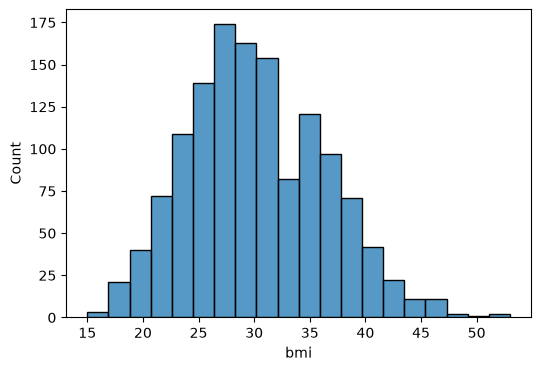

In [286]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['bmi'],bins=20)

In [287]:
df_clean['bmi_catagory']=pd.cut(
    df_clean['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['underweight','normal','overweight','obesed']
)

In [288]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_catagory
0,19,1,27,0,1,16884,0,0,0,1,overweight
1,18,0,33,1,0,1725,0,0,1,0,obesed
2,28,0,33,3,0,4449,0,0,1,0,obesed
3,33,0,22,0,0,21984,0,1,0,0,normal
4,32,0,28,0,0,3866,0,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,obesed
1334,18,1,31,0,0,2205,1,0,0,0,obesed
1335,18,1,36,0,0,1629,0,0,1,0,obesed
1336,21,1,25,0,0,2007,0,0,0,1,overweight


In [289]:
df_clean=pd.get_dummies(df_clean,columns=['bmi_catagory'])

In [290]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_catagory_underweight,bmi_catagory_normal,bmi_catagory_overweight,bmi_catagory_obesed
0,19,1,27,0,1,16884,0,0,0,1,False,False,True,False
1,18,0,33,1,0,1725,0,0,1,0,False,False,False,True
2,28,0,33,3,0,4449,0,0,1,0,False,False,False,True
3,33,0,22,0,0,21984,0,1,0,0,False,True,False,False
4,32,0,28,0,0,3866,0,1,0,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,False,False,False,True
1334,18,1,31,0,0,2205,1,0,0,0,False,False,False,True
1335,18,1,36,0,0,1629,0,0,1,0,False,False,False,True
1336,21,1,25,0,0,2007,0,0,0,1,False,False,True,False


In [291]:
df_clean=df_clean.astype(int)

In [292]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_catagory_underweight,bmi_catagory_normal,bmi_catagory_overweight,bmi_catagory_obesed
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


# Feature Selection

In [293]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable


In [294]:
from sklearn.preprocessing import StandardScaler


In [295]:
cols= [ 'age','bmi','children']
scalere = StandardScaler()
df_clean[cols]= scalere.fit_transform(df_clean[cols])

In [296]:
df_clean

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_catagory_underweight,bmi_catagory_normal,bmi_catagory_overweight,bmi_catagory_obesed
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1,0,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,1,0,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,0,1,0,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,0,1,0,0,1,0


In [297]:
df_clean.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_catagory_underweight', 'bmi_catagory_normal',
       'bmi_catagory_overweight', 'bmi_catagory_obesed'],
      dtype='str')

<Axes: >

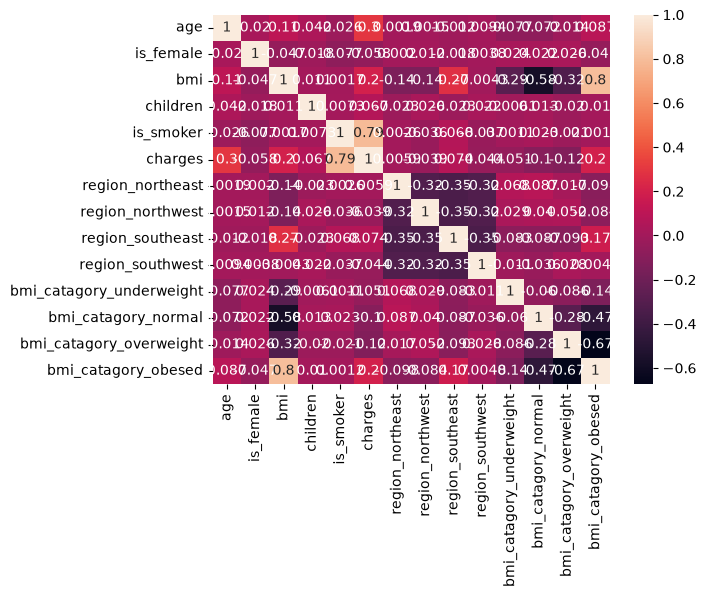

In [298]:
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)

In [299]:
from scipy.stats import pearsonr


selected_feature = [
    'age', 'is_female', 'bmi', 'children', 'smoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_catagory_underweight', 'bmi_catagory_normal',
       'bmi_catagory_overweight', 'bmi_catagory_obesed'
       ]


correlations = {
    feature: pearsonr(df_clean[feature], df_clean['charges'])[0]
    for feature in selected_feature
}

KeyError: 'smoker'

In [ ]:
for feature, correlation in correlations.items():
    print(feature, ":", correlation)

age : 0.29830870258771736
is_female : -0.05804580933726394
bmi : 0.1962362929936443
children : 0.06739024185912061
smoker : 0.7872337542693594
region_northeast : 0.00594621913354778
region_northwest : -0.03869515161276133
region_southeast : 0.07357719339126033
region_southwest : -0.04363698192991321
bmi_catagory_underweight : -0.05059936391871634
bmi_catagory_normal : -0.10404195904728353
bmi_catagory_overweight : -0.12060129307098051
bmi_catagory_obesed : 0.20034756980289617


In [ ]:
correlations_df = pd.DataFrame(list(correlations.items()),columns=['Features','Pearson Correlation'])

In [ ]:
correlations_df

,Features,Pearson Correlation
0,age,0.298309
1,is_female,-0.058046
2,bmi,0.196236
3,children,0.067390
4,smoker,0.787234
5,region_northeast,0.005946
6,region_northwest,-0.038695
7,region_southeast,0.073577
8,region_southwest,-0.043637
9,bmi_catagory_underweight,-0.050599


In [ ]:
cat_features = [
    'is_female', 'is_smoker',
   'region_northeast','region_northwest', 'region_southeast', 'region_southwest',
    'bmi_catagory_underweight','bmi_catagory_normal', 'bmi_catagory_overweight', 'bmi_catagory_obesed'
]

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.5
df_clean['charges_bin'] = pd.qcut(df_clean['charges'],q=4,labels=False)

chi2_results = {}



In [ ]:
for col in cat_features:
    contingency = pd.crosstab(df_clean[col], df_clean['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

In [ ]:

chi2_results

{'is_female': {'chi2_statistic': np.float64(10.258784131896034),
  'p_value': np.float64(0.016489740254825688),
  'Decision': 'Reject Null (Keep Feature)'},
 'is_smoker': {'chi2_statistic': np.float64(848.2191784691495),
  'p_value': np.float64(1.5074776554531109e-183),
  'Decision': 'Reject Null (Keep Feature)'},
 'region_northeast': {'chi2_statistic': np.float64(6.438442307376374),
  'p_value': np.float64(0.09212205767134653),
  'Decision': 'Reject Null (Keep Feature)'},
 'region_northwest': {'chi2_statistic': np.float64(1.1342403613235656),
  'p_value': np.float64(0.76881540917986),
  'Decision': 'Accept Null (Drop Feature)'},
 'region_southeast': {'chi2_statistic': np.float64(15.998167448977355),
  'p_value': np.float64(0.0011349657141180658),
  'Decision': 'Reject Null (Keep Feature)'},
 'region_southwest': {'chi2_statistic': np.float64(5.091893034250699),
  'p_value': np.float64(0.1651906331216363),
  'Decision': 'Reject Null (Keep Feature)'},
 'bmi_catagory_underweight': {'chi2_

In [304]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')

chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_catagory_obesed,8.515711,0.036473,Reject Null (Keep Feature)
region_northeast,6.438442,0.092122,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Reject Null (Keep Feature)
bmi_catagory_overweight,4.25149,0.235557,Reject Null (Keep Feature)
bmi_catagory_normal,3.708088,0.29476,Reject Null (Keep Feature)
bmi_catagory_underweight,3.37403,0.337471,Reject Null (Keep Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [303]:
chi2_df.columns

Index(['is_female', 'is_smoker', 'region_northeast', 'region_northwest',
       'region_southeast', 'region_southwest', 'bmi_catagory_underweight',
       'bmi_catagory_normal', 'bmi_catagory_overweight',
       'bmi_catagory_obesed'],
      dtype='str')

In [305]:
final_df=df_clean[['is_female', 'is_smoker', 'region_northeast',
       'region_southeast', 'region_southwest', 'bmi_catagory_underweight',
       'bmi_catagory_normal', 'bmi_catagory_overweight',
       'bmi_catagory_obesed']]

In [308]:
final_df

,is_female,is_smoker,region_northeast,region_southeast,region_southwest,bmi_catagory_underweight,bmi_catagory_normal,bmi_catagory_overweight,bmi_catagory_obesed
0,1,1,0,0,1,0,0,1,0
1,0,0,0,1,0,0,0,0,1
2,0,0,0,1,0,0,0,0,1
3,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...
1333,0,0,0,0,0,0,0,0,1
1334,1,0,1,0,0,0,0,0,1
1335,1,0,0,1,0,0,0,0,1
1336,1,0,0,0,1,0,0,1,0
